## RNN (Using Autoregressive Multiple-Step Approch)

* Predict future steps recursively using model’s previous output as input.

* Feedback loop is used where predictions become inputs for the next step. 

In the below code We have used Sequence Length = 10 i.e. using 10 ground truth values from test dataset, whole test dataset will be predicted  by appending the predicted values into the array

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_7 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1494 - val_loss: 0.0088
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0073 - val_loss: 0.0038
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052 - val_loss: 0.0033
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - val_loss: 0.0027
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047 - val_loss: 0.0026
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - val_loss: 0.0027
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036 - val_loss: 0.0025
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0030 - val_loss: 0.0040
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

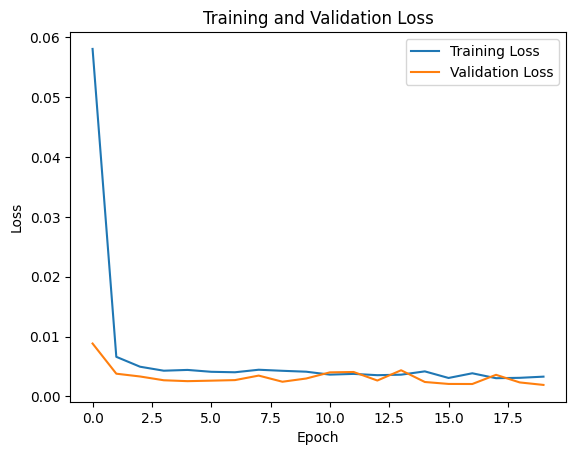

      SN  Actual IP Delay (ms)  Recursive Predicted IP Delay (ms)  \
99   100             19.124985                          17.274230   
100  101             19.055128                          17.220406   
101  102             18.997908                          17.165429   
102  103             18.989086                          17.109260   
103  104             18.851042                          17.051616   
..   ...                   ...                                ...   
195  196             18.092155                          17.460977   
196  197             18.032074                          17.411277   
197  198             17.966032                          17.360412   
198  199             17.963171                          17.308426   
199  200             17.861843                          17.255347   

     Absolute Difference (ms)  
99                   1.850755  
100                  1.834722  
101                  1.832479  
102                  1.879826  
103        

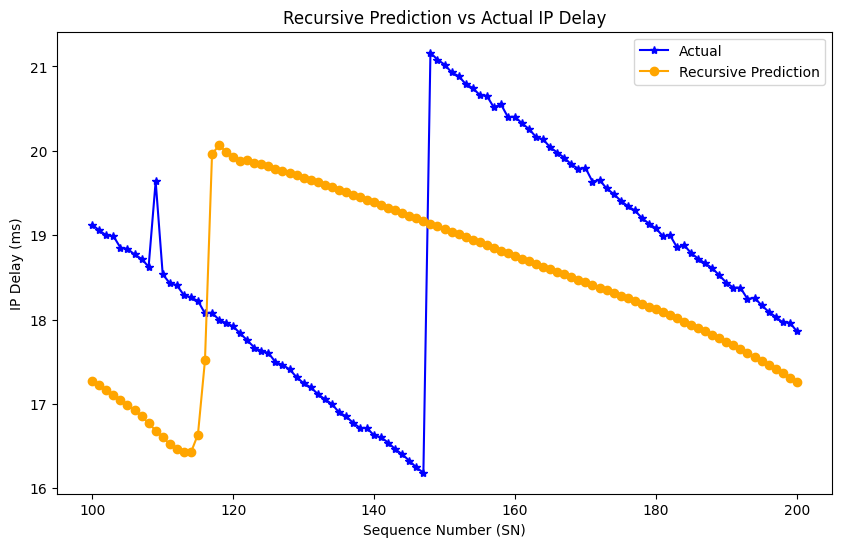

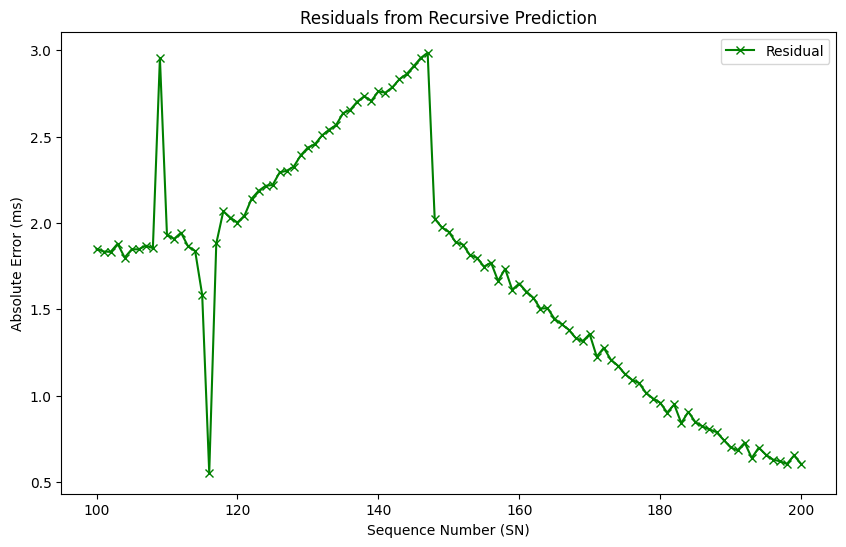

Residual Statistics:
 count    3490.000000
mean        1.457179
std         1.004826
min         0.000203
25%         0.632345
50%         1.297509
75%         2.145804
max         5.442255
Name: Absolute Difference (ms), dtype: float64


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 10

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build RNN model
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=100) & (recursive_df['SN'] <=200)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_prediction_10.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


In the below code We have used Sequence Length = 100 i.e. using 100 ground truth values from test dataset, whole test dataset will be predicted  by appending the predicted values into the array

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0279 - val_loss: 0.0049
Epoch 2/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 3/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0059 - val_loss: 0.0062
Epoch 4/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 5/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0045 - val_loss: 0.0068
Epoch 6/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0046 - val_loss: 0.0032
Epoch 7/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 8/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 9/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 10/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0032 - val_loss: 0.0028
Epoch 11/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 12/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

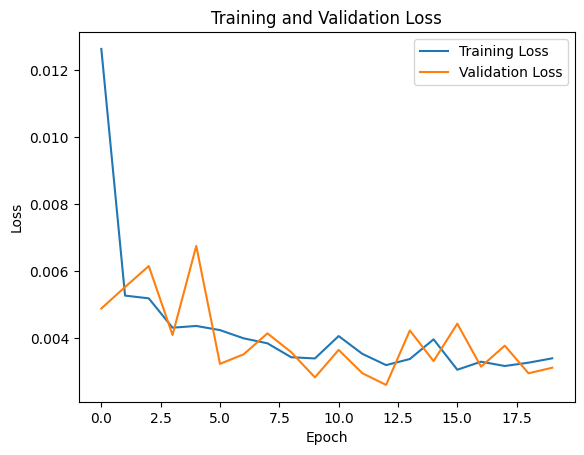

      SN  Actual IP Delay (ms)  Recursive Predicted IP Delay (ms)  \
99   100             18.436909                          17.238395   
100  101             18.377066                          17.180528   
101  102             18.377066                          17.116130   
102  103             18.243074                          17.044375   
103  104             18.256903                          16.961604   
..   ...                   ...                                ...   
195  196             17.472029                          16.442022   
196  197             17.371178                          16.532146   
197  198             17.314911                          16.807279   
198  199             17.245054                          17.420545   
199  200             17.222166                          17.533780   

     Absolute Difference (ms)  
99                   1.198513  
100                  1.196538  
101                  1.260936  
102                  1.198699  
103        

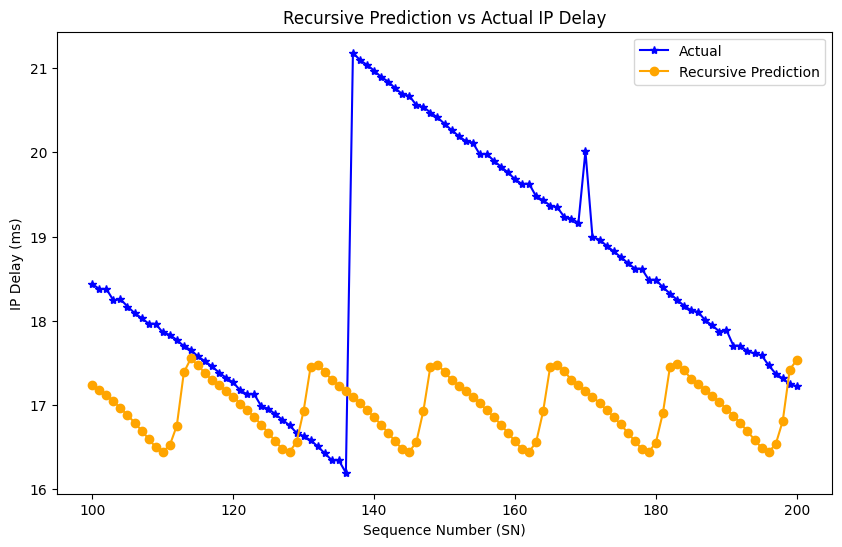

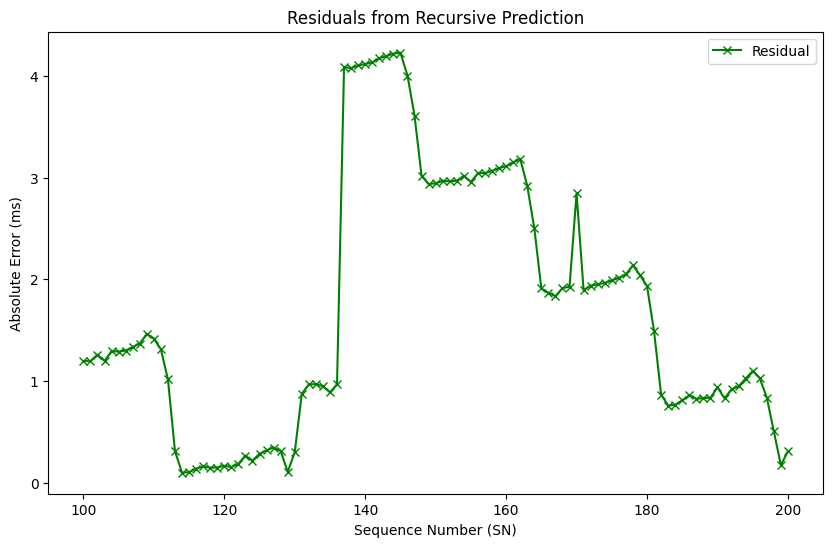

Residual Statistics:
 count    3400.000000
mean        1.852890
std         1.305036
min         0.000462
25%         0.669443
50%         1.685269
75%         2.957297
max         4.754958
Name: Absolute Difference (ms), dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 100

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build RNN model
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=100) & (recursive_df['SN'] <=200)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_prediction_100.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


In the below code We have used Sequence Length = 20 i.e. using 20 ground truth values from test dataset, whole test dataset will be predicted  by appending the predicted values into the array

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0438 - val_loss: 0.0070
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0066 - val_loss: 0.0048
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - val_loss: 0.0044
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052 - val_loss: 0.0041
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0040 - val_loss: 0.0034
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - val_loss: 0.0035
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043 - val_loss: 0.0035
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - val_loss: 0.0031
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041 - val_loss: 0.0032
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

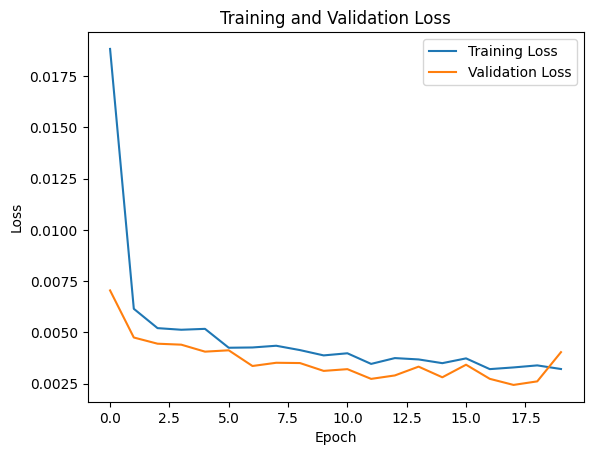

      SN  Actual IP Delay (ms)  Recursive Predicted IP Delay (ms)  \
99   100             18.535852                          17.510698   
100  101             18.430948                          17.452427   
101  102             18.406868                          17.394570   
102  103             18.290043                          17.336739   
103  104             18.261909                          17.278871   
..   ...                   ...                                ...   
195  196             17.518997                          18.952245   
196  197             17.457962                          18.896341   
197  198             17.384052                          18.840406   
198  199             17.322063                          18.784523   
199  200             17.267942                          18.728739   

     Absolute Difference (ms)  
99                   1.025154  
100                  0.978521  
101                  1.012298  
102                  0.953304  
103        

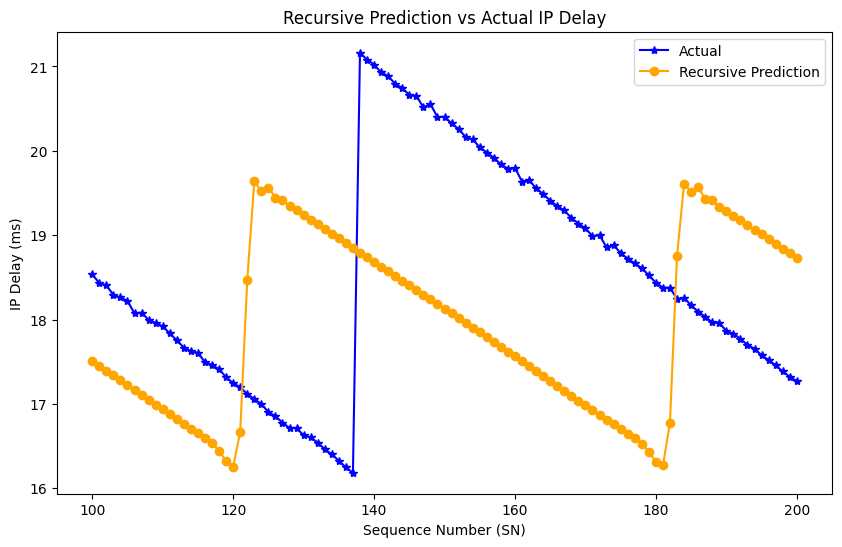

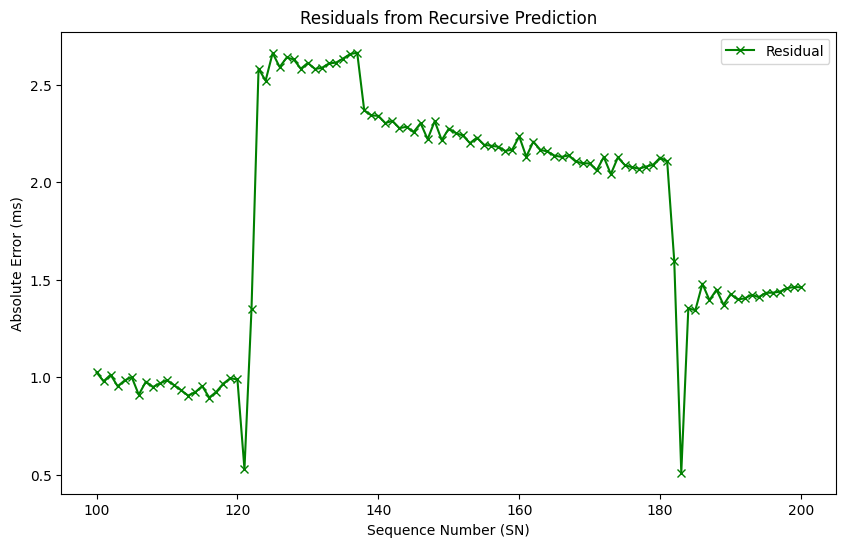

Residual Statistics:
 count    3480.000000
mean        1.535712
std         1.079375
min         0.001481
25%         0.615539
50%         1.363994
75%         2.208414
max         4.932021
Name: Absolute Difference (ms), dtype: float64


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 20

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build RNN model
model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=100) & (recursive_df['SN'] <=200)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_prediction_20.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


        SN  Actual IP Delay (ms)  Recursive Predicted IP Delay (ms)  \
0     1746             20.681143                          20.650722   
1     1747             20.609856                          20.603867   
2     1748             20.556927                          20.516021   
3     1749             20.544052                          20.440119   
4     1750             20.488977                          20.364891   
...    ...                   ...                                ...   
1740  3486             21.203041                          17.427345   
1741  3487             21.198988                          17.358327   
1742  3488             21.097898                          17.290860   
1743  3489             21.007061                          17.222177   
1744  3490             20.949125                          17.152291   

      Absolute Difference (ms)  
0                     0.030421  
1                     0.005989  
2                     0.040906  
3              

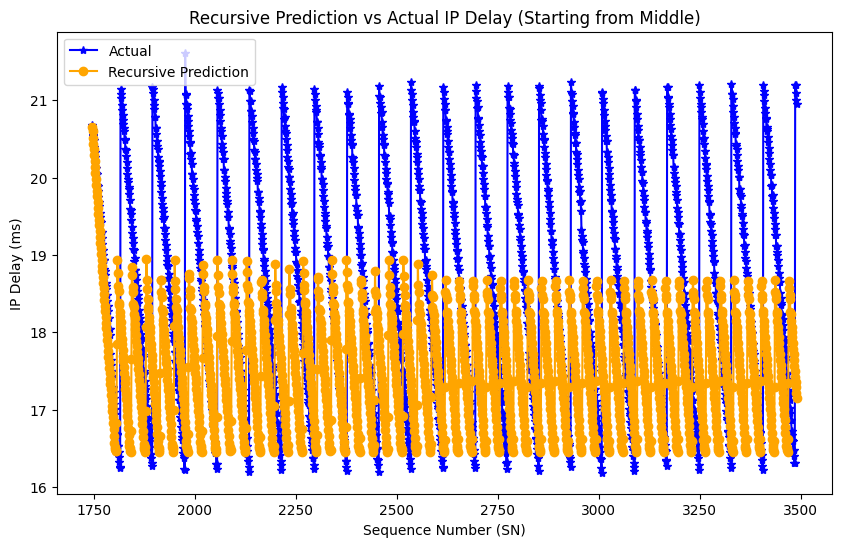

In [21]:
# Choose a sequence from the middle of the test dataset
middle_index = len(X_test) // 2  # Get the midpoint index
initial_sequence = X_test[middle_index].reshape(-1, 1)  # Start from middle sequence

recursive_steps = len(y_test) - middle_index  # Adjust steps to avoid index overflow
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test[middle_index:] * (max_test - min_test)) + min_test  # Adjust comparison range

# Build updated comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(middle_index + 1, middle_index + recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Print updated comparison
print(recursive_df)

# Plot updated results
plt.figure(figsize=(10, 6))
plt.plot(recursive_df['SN'], recursive_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(recursive_df['SN'], recursive_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay (Starting from Middle)')
plt.legend()
plt.show()



       SN  Actual IP Delay (ms)  Recursive Predicted IP Delay (ms)  \
354  2100             18.368006                          18.128810   
355  2101             18.280983                          18.055997   
356  2102             18.269062                          17.983691   
357  2103             18.197060                          17.909848   
358  2104             18.129826                          17.837942   
..    ...                   ...                                ...   
450  2196             17.354965                          16.528824   
451  2197             17.275095                          17.054742   
452  2198             17.205954                          18.155011   
453  2199             17.184973                          18.887481   
454  2200             17.116070                          18.616546   

     Absolute Difference (ms)  
354                  0.239196  
355                  0.224986  
356                  0.285371  
357                  0.287211  

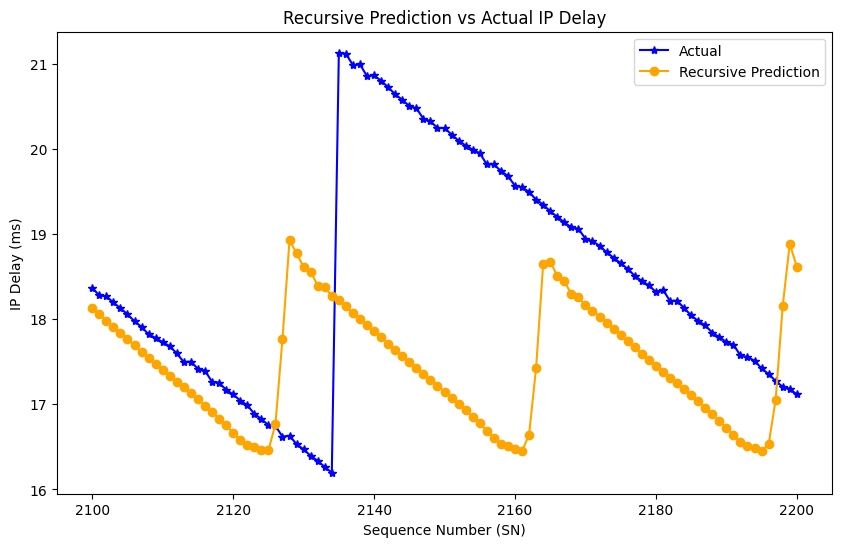

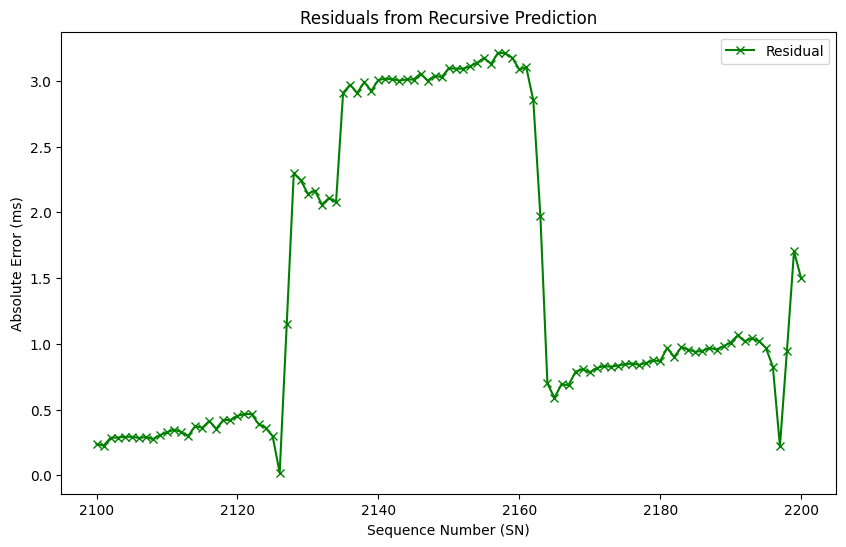

In [24]:
# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=2100) & (recursive_df['SN'] <=2200)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()